In [58]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

from src.utils import *
from src.yoloEval import *
from src.localBoundingBoxSearch import *

import os
from pathlib import Path

In [59]:
inference = Inference("models_weights/yolo11n.pt")
bbSearcher = BBSearcher(threshold=100)

(np.float64(-0.5), np.float64(880.5), np.float64(399.5), np.float64(-0.5))

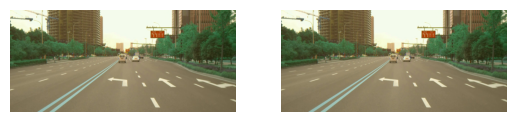

In [60]:
path_r = Path("right_img_folder/2018-07-09-16-11-56_2018-07-09-16-11-56-502.jpg")
path_l = Path("left_img_folder/2018-07-09-16-11-56_2018-07-09-16-11-56-502.jpg")

img_r = cv2.imread(path_r)
img_l = cv2.imread(path_l)

fig, ax = plt.subplots(1, 2); ax[0].imshow(img_l); ax[0].axis('off'); ax[1].imshow(img_l); ax[1].axis('off')

In [61]:
framer, boxes_and_classes_r = inference.pipeline(path_r)
framel, boxes_and_classes_l = inference.pipeline(path_l)

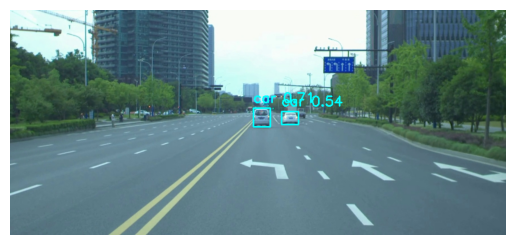

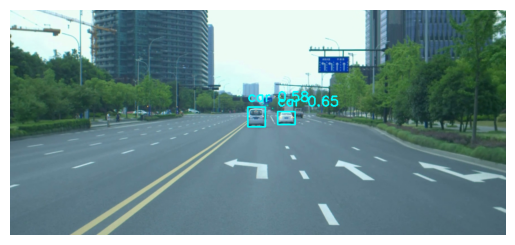

In [62]:
inference.plot_bounding_box(path_r)
inference.plot_bounding_box(path_l)

In [63]:
pairs = bbSearcher.pipeline(boxes_and_classes_l, boxes_and_classes_r)

debug


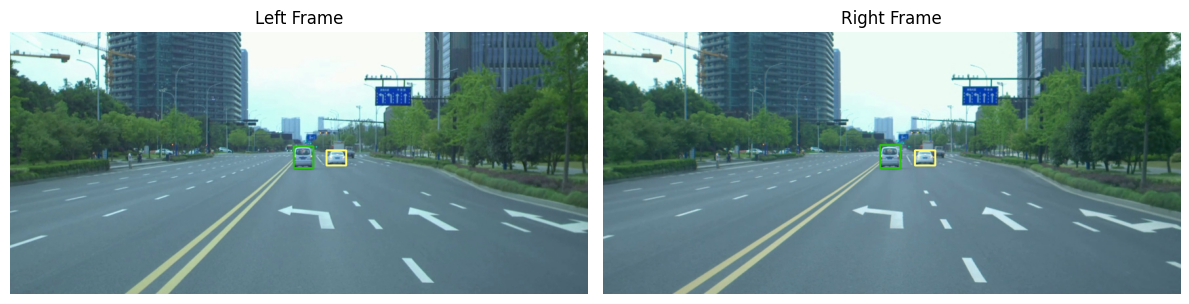

In [64]:
plotBBPairs(framer, framel, pairs)

In [65]:
valid_extensions = (".jpg", ".jpeg", ".png", ".webp", ".bmp")

left_images = [
    os.path.join(root, file)
    for root, _, files in os.walk("left_img_folder")
    for file in files
    if file.lower().endswith(valid_extensions)
][:100]

right_images = [
    os.path.join(root, file)
    for root, _, files in os.walk("right_img_folder")
    for file in files
    if file.lower().endswith(valid_extensions)
][:100]

debug
debug
debug
debug


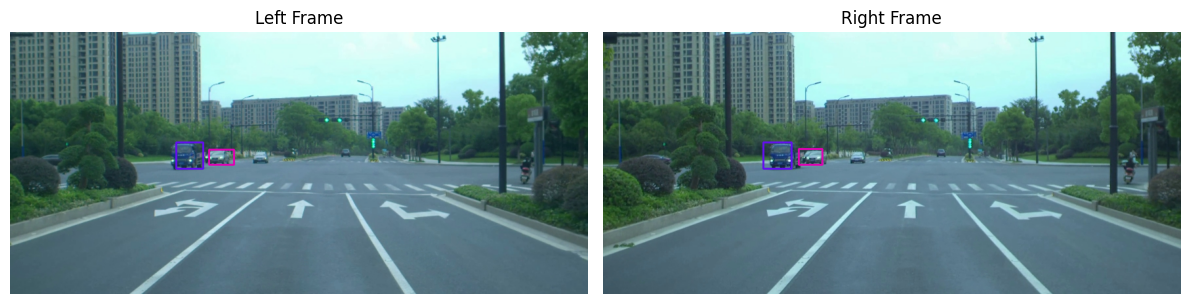

error: OpenCV(4.12.0) /io/opencv/modules/imgproc/src/color.cpp:199: error: (-215:Assertion failed) !_src.empty() in function 'cvtColor'


In [ ]:
for i_l, i_r in zip(left_images, right_images):
    framel, boxes_and_classes_l = inference.pipeline(i_l)
    framer, boxes_and_classes_r = inference.pipeline(i_r)

    pairs = bbSearcher.pipeline(boxes_and_classes_l, boxes_and_classes_r)

    img = plotBBPairs(framel, framer, pairs)

    img_bgr = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)
    
    cv2.imshow("Stereo Bounding Box Matching", img_bgr)

    # POPRAWKA 3: Zmień na 0, jeśli chcesz zatrzymywać każdą klatkę do wciśnięcia klawisza
    if cv2.waitKey(0) & 0xFF == ord("q"):  # Naciśnij 'q' aby przerwać
        break

cv2.destroyAllWindows()